<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
import urllib.request

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"

urllib.request.urlretrieve(url, "survey-data.sqlite")

print("Download completed")

Download completed


In [3]:
!pip install pandas

In [4]:
!pip install matplotlib

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [9]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [10]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [11]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [26]:
QUERY="""
SELECT *
FROM main
"""
df= pd.read_sql_query(QUERY, conn)

In [19]:
!pip install seaborn
import seaborn as sns

In [22]:
!pip install numpy
import numpy as np

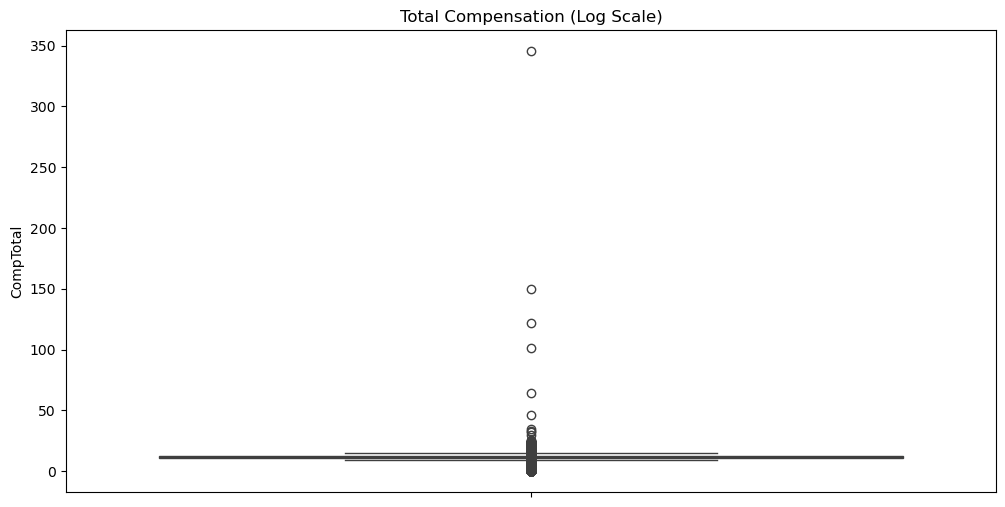

In [24]:
# your code goes here
plt.figure(figsize=(12,6))
sns.boxplot(y=np.log1p(df['CompTotal'].dropna()))
plt.title('Total Compensation (Log Scale)')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


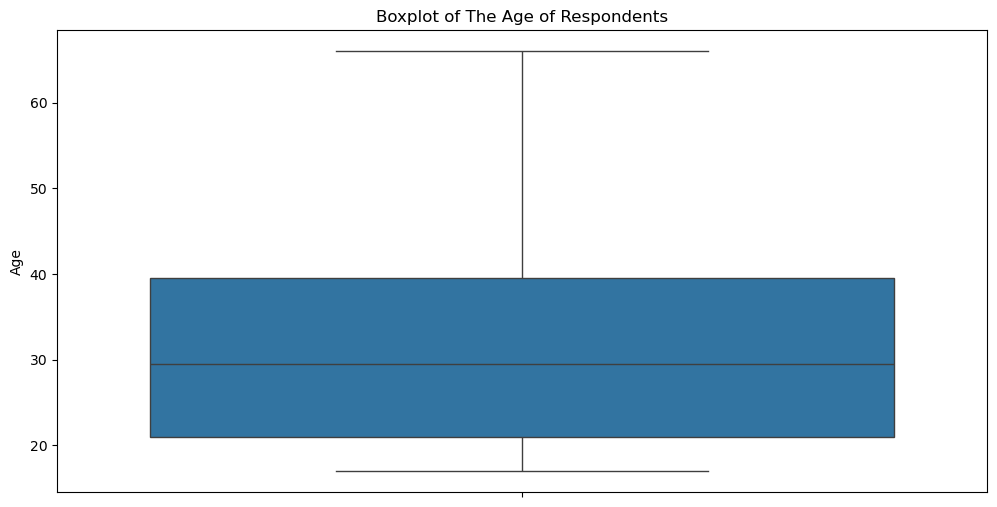

In [27]:
# your code goes here
age_map= {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}

df['Age_num']= df['Age'].map(age_map)
df_clean= df.dropna(subset='Age_num').copy()

plt.figure(figsize=(12,6))
sns.boxplot(y=df_clean['Age_num'])
plt.title('Boxplot of The Age of Respondents')
plt.ylabel("Age")
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


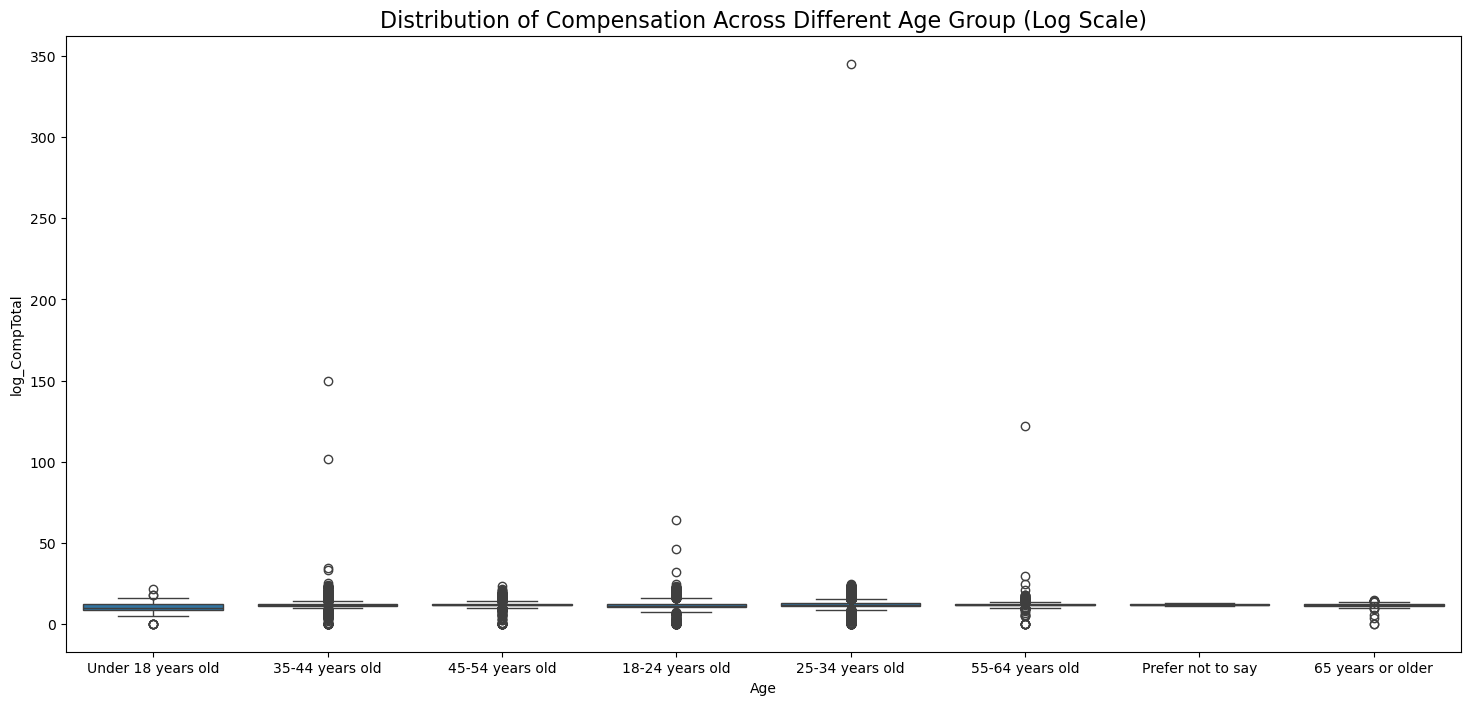

In [36]:
# your code goes here
plt.figure(figsize=(18,8))
df['log_CompTotal']= np.log1p(df['CompTotal'])
labels=df['Age'].unique()
sns.boxplot(data=df, x='Age', y='log_CompTotal')
plt.title('Distribution of Compensation Across Different Age Group (Log Scale)', fontsize=16)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


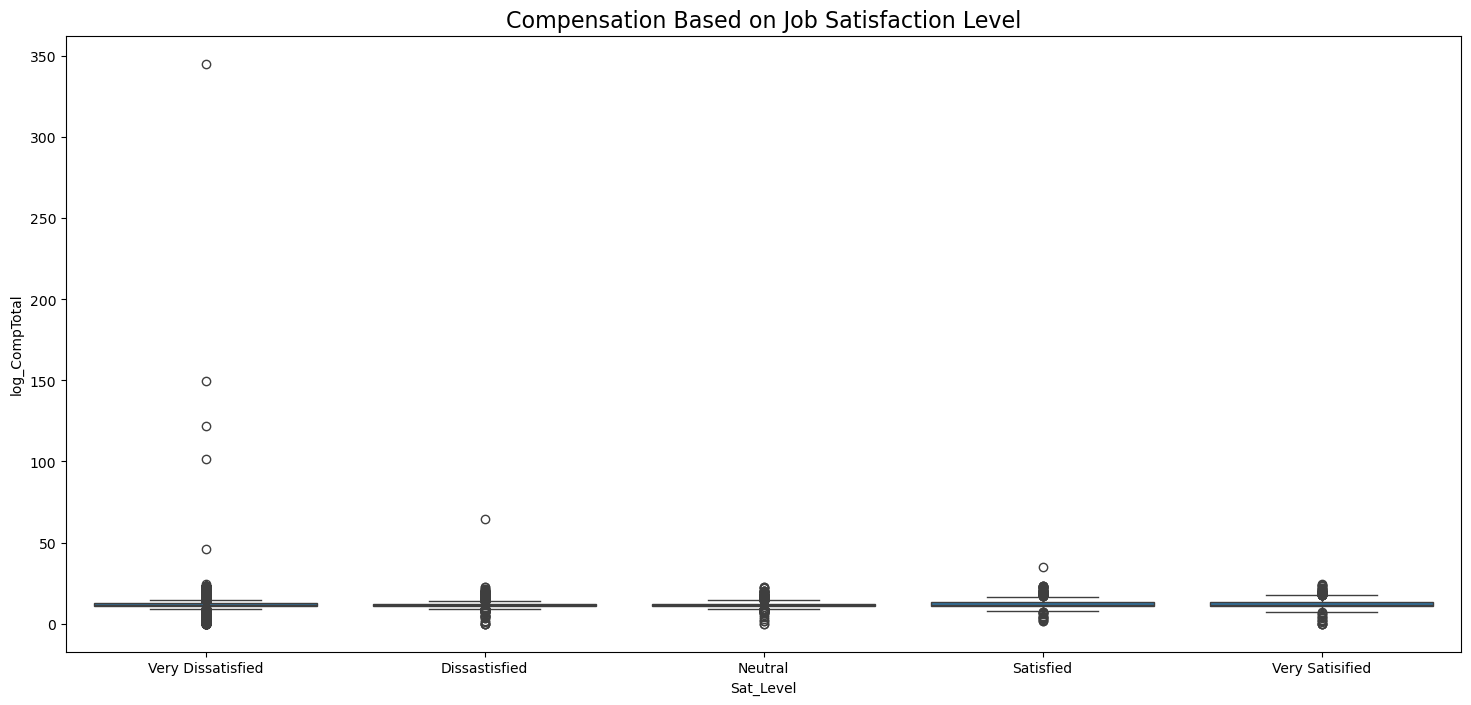

In [41]:
# your code goes here
bins=[0,20,40,60,80,100]
labels=['Very Dissatisfied', 'Dissastisfied', 'Neutral', 'Satisfied', 'Very Satisified']
df['Sat_Level']= pd.cut(df['JobSatPoints_6'].astype(float), bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(18,8))
sns.boxplot(data=df, x='Sat_Level', y='log_CompTotal')
plt.title('Compensation Based on Job Satisfaction Level', fontsize=16)
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


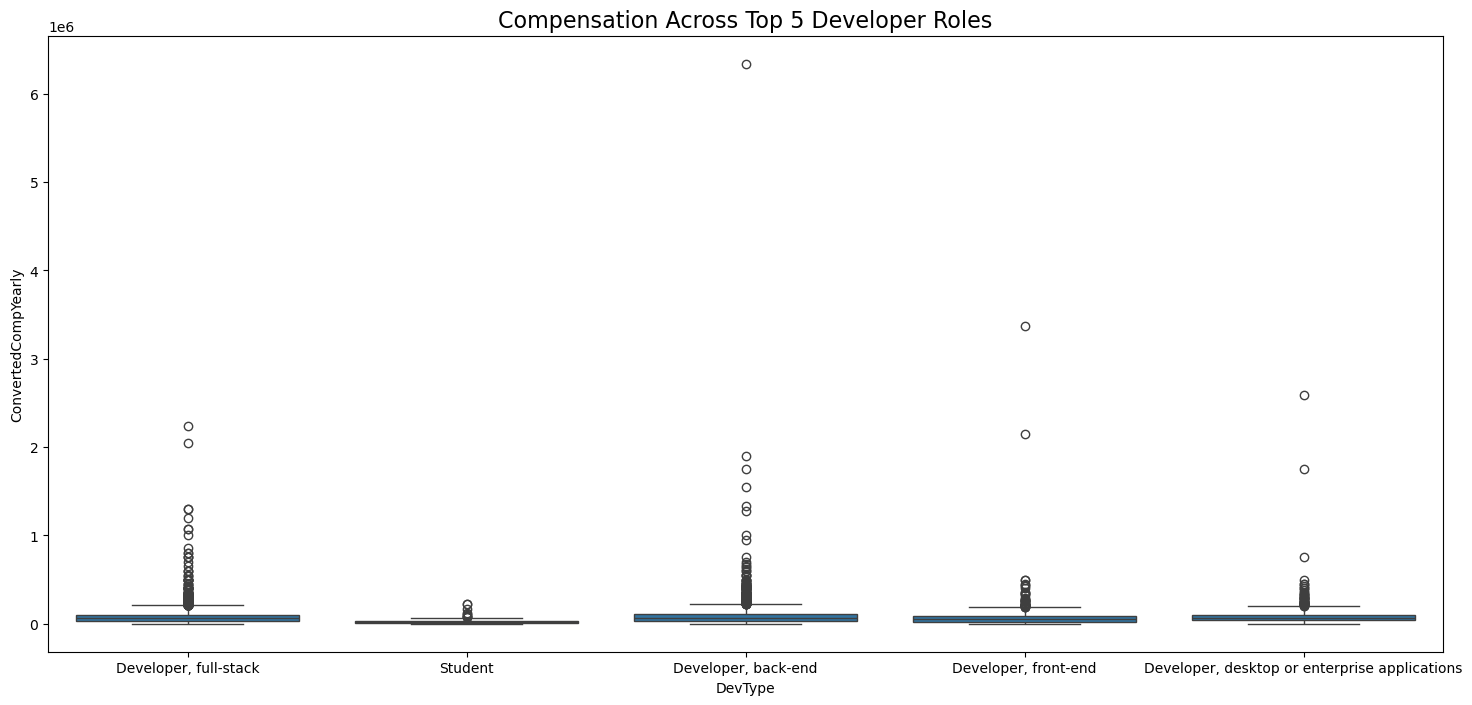

In [57]:
# your code goes here
top_5developer=df['DevType'].value_counts().head(5)
df_dev=df[df['DevType'].isin(top_5developer.index)]

plt.figure(figsize=(18,8))
sns.boxplot(data=df_dev, x='DevType', y='ConvertedCompYearly')
plt.title('Compensation Across Top 5 Developer Roles', fontsize=16)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


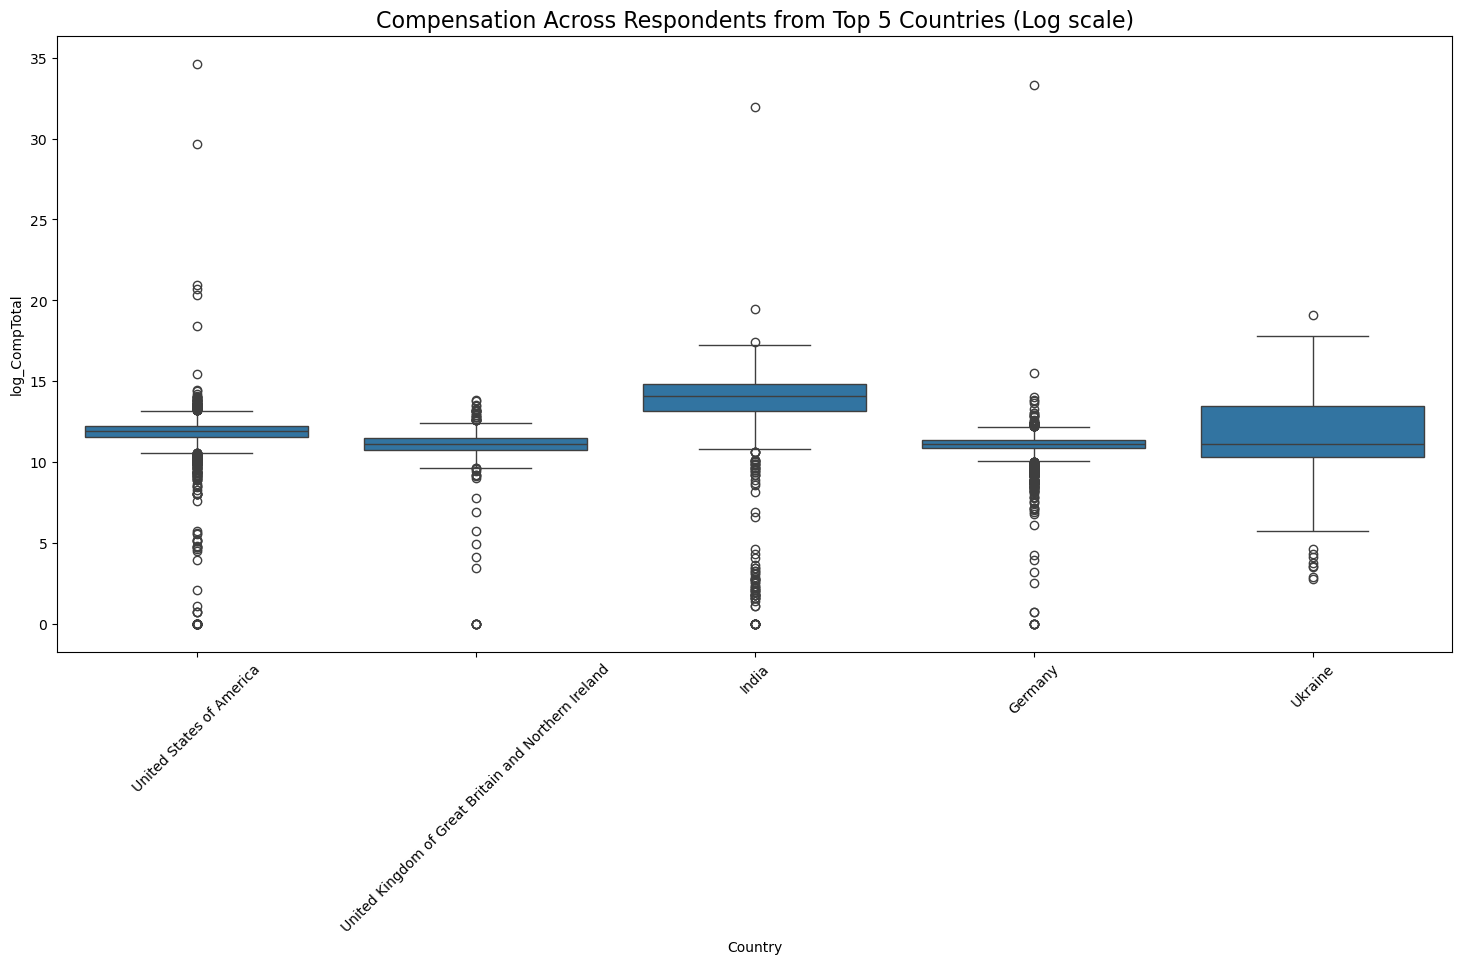

In [62]:
# your code goes here
top_5countries= df['Country'].value_counts().head(5)
df_country= df[df['Country'].isin(top_5countries.index)]

plt.figure(figsize=(18,8))
sns.boxplot(data= df_country, x='Country', y='log_CompTotal')
plt.title('Compensation Across Respondents from Top 5 Countries (Log scale)', fontsize=16)
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


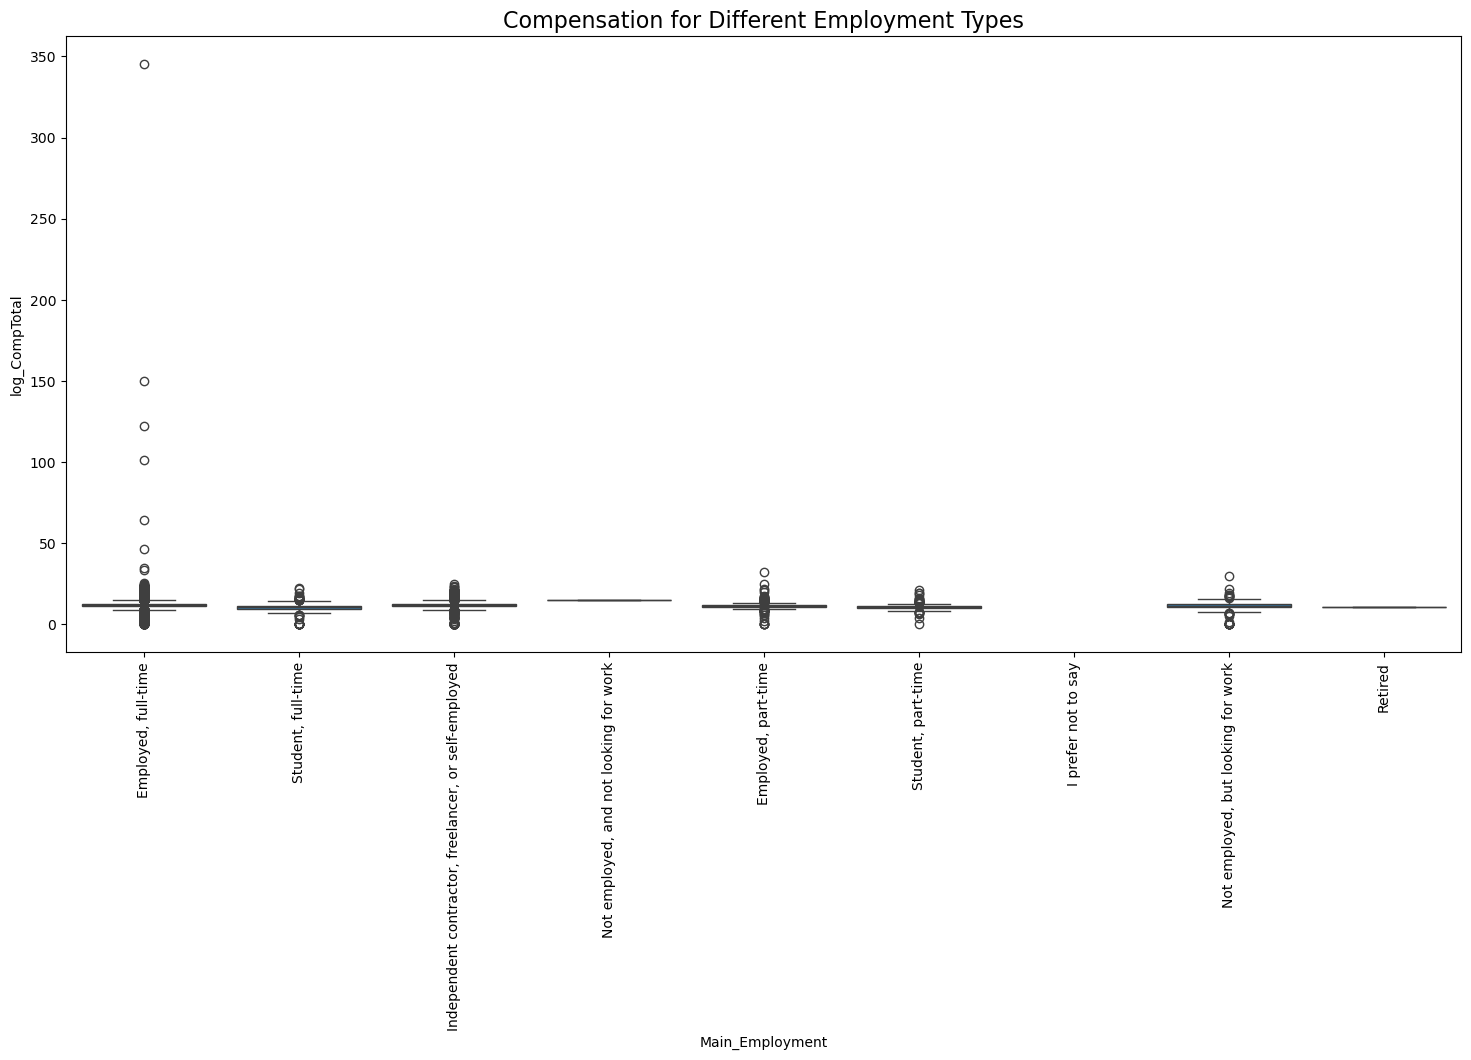

In [71]:
# your code goes here
df['Main_Employment']= df['Employment'].str.split(';').str[0]

plt.figure(figsize=(18,8))
sns.boxplot(data=df, x='Main_Employment', y='log_CompTotal')
plt.title('Compensation for Different Employment Types', fontsize=16)
plt.xticks(rotation=90)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [73]:
df['YearsCodePro']= df['YearsCodePro'].replace({'Less than 1 year': 0.5, 'More than 50 years': 51})
df['YearsCodePro']= pd.to_numeric(df['YearsCodePro'], errors='coerce')

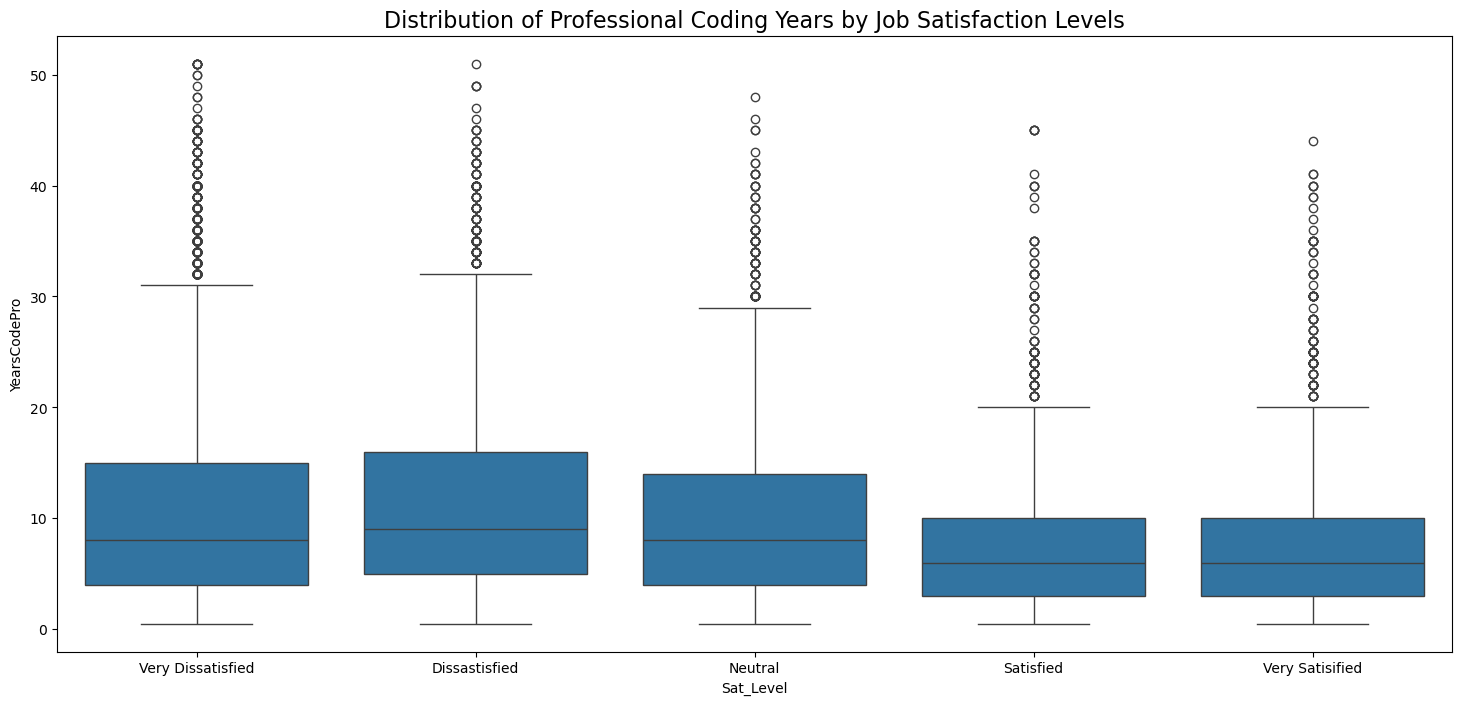

In [75]:
# your code goes here
plt.figure(figsize=(18,8))
sns.boxplot(data=df, x='Sat_Level', y='YearsCodePro')
plt.title('Distribution of Professional Coding Years by Job Satisfaction Levels', fontsize=16)
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [76]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
